# Laboratorio 5 – Naive Bayes

**Continuación directa del Lab 4** — se reutilizan el mismo dataset preprocesado,
el mismo `train_test_split(random_state=42)` y la misma variable categórica `price_category`.


## Configuración
Reutilizar todo el pipeline del Lab 4

In [1]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print("Librerías cargadas.")


Librerías cargadas.


In [2]:
# PASO 1: Cargar datos
result = pyreadr.read_r('listings.Rdata')
df_raw = result[list(result.keys())[0]].copy()

# PASO 2: Limpiar precio
df = df_raw.copy()
if df['price'].dtype == object:
    df['price'] = (df['price'].str.replace(r'[\$,]', '', regex=True)
                   .str.strip().replace('', np.nan).astype(float))
q_high = df['price'].quantile(0.99)
df = df[(df['price'] > 0) & (df['price'] <= q_high)].copy()

# PASO 3: Eliminar columnas irrelevantes
cols_to_drop = ['id','listing_url','scrape_id','last_scraped','source','name',
    'description','neighborhood_overview','picture_url','host_url',
    'host_thumbnail_url','host_picture_url','host_about','host_verifications',
    'amenities','calendar_updated','calendar_last_scraped','license',
    'bathrooms_text','minimum_minimum_nights','maximum_minimum_nights',
    'minimum_maximum_nights','maximum_maximum_nights',
    'minimum_nights_avg_ntm','maximum_nights_avg_ntm']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
null_pct = df.isnull().mean()
df = df.drop(columns=null_pct[null_pct > 0.60].index.tolist())

# PASO 4: Ingeniería de fechas
if 'host_since' in df.columns:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_years'] = ((pd.Timestamp('2024-01-01') - df['host_since']).dt.days / 365).round(1)
    df = df.drop(columns=['host_since'])
df = df.drop(columns=[c for c in ['first_review','last_review'] if c in df.columns], errors='ignore')

# PASO 5: Booleanos y tasas
for col in ['host_is_superhost','host_has_profile_pic','host_identity_verified',
            'has_availability','instant_bookable']:
    if col in df.columns:
        df[col] = df[col].map({'t':1,'f':0,True:1,False:0})
for col in ['host_response_rate','host_acceptance_rate']:
    if col in df.columns:
        df[col] = df[col].str.replace('%','',regex=False).str.strip().astype(float, errors='ignore')

# PASO 6: Selección y OHE
TARGET = 'price'
num_features = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
cat_features = [c for c in ['room_type','property_type','neighbourhood_cleansed',
                              'host_response_time'] if c in df.columns]
for col in cat_features:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].replace(freq[freq < 0.01].index, 'Otro')
df_encoded = pd.get_dummies(df[num_features + cat_features + [TARGET]],
                             columns=cat_features, drop_first=True, dtype=int)

# PASO 7: Imputar nulos
for col in df_encoded.columns:
    if df_encoded[col].isnull().any():
        df_encoded[col].fillna(df_encoded[col].median(), inplace=True)

# PASO 8: Variable categórica (igual que Lab 4)
p33 = df_encoded[TARGET].quantile(0.33)
p67 = df_encoded[TARGET].quantile(0.67)
def categorize_price(p):
    if p <= p33: return 'Económico'
    elif p <= p67: return 'Intermedio'
    else: return 'Caro'
df_encoded['price_category'] = df_encoded[TARGET].apply(categorize_price)

# PASO 9: Split IDÉNTICO al Lab 4 (random_state=42, test_size=0.20)
feature_cols = [c for c in df_encoded.columns if c not in [TARGET, 'cluster', 'price_category']]
X = df_encoded[feature_cols]
y = df_encoded[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# PASO 10: Split clasificación (estratificado, igual que Lab 4)
le = LabelEncoder()
y_clf_enc = le.fit_transform(df_encoded['price_category'])
X_clf = df_encoded[feature_cols]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf_enc, test_size=0.20, random_state=42, stratify=y_clf_enc)

print(f"Dataset: {df_encoded.shape[0]:,} filas × {len(feature_cols)} features")
print(f"Train regresión:      {len(X_train):,}   Test: {len(X_test):,}")
print(f"Train clasificación:  {len(X_train_c):,}   Test: {len(X_test_c):,}")
print(f"Categorías: P33=${p33:.0f}  P67=${p67:.0f}")
print(f"Clases: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("Pipeline Lab 4.")


Dataset: 75,531 filas × 73 features
Train regresión:      60,424   Test: 15,107
Train clasificación:  60,424   Test: 15,107
Categorías: P33=$140  P67=$267
Clases: {'Caro': 0, 'Económico': 1, 'Intermedio': 2}
Pipeline Lab 4.


In [3]:
# Re-entrenar modelos del Lab 4 para tener sus predicciones disponibles
# Árbol de regresión (mejor: depth=12)
t_start = time.time()
best_tree_reg = DecisionTreeRegressor(max_depth=12, min_samples_split=50, random_state=42)
best_tree_reg.fit(X_train, y_train)
yp_tree_reg = best_tree_reg.predict(X_test)
t_tree_reg = time.time() - t_start

# Random Forest regresión
t_start = time.time()
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=10,
                                min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
yp_rf_reg = rf_reg.predict(X_test)
t_rf_reg = time.time() - t_start

# Ridge Regresión
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
y_train_log = np.log1p(y_train)
t_start = time.time()
ridge_cv = RidgeCV(alphas=np.logspace(-3,3,50), cv=5)
ridge_cv.fit(X_train_sc, y_train_log)
yp_ridge = np.expm1(ridge_cv.predict(X_test_sc))
t_ridge = time.time() - t_start

# Árbol de clasificación (mejor: depth=15)
t_start = time.time()
best_tree_clf = DecisionTreeClassifier(max_depth=15, random_state=42)
best_tree_clf.fit(X_train_c, y_train_c)
yp_tree_clf = best_tree_clf.predict(X_test_c)
t_tree_clf = time.time() - t_start

# Random Forest clasificación
t_start = time.time()
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=10,
                                 min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
yp_rf_clf = rf_clf.predict(X_test_c)
t_rf_clf = time.time() - t_start

print("Modelos del Lab anterior.")
print(f"  Árbol regresión:   {t_tree_reg:.2f}s")
print(f"  Random Forest reg: {t_rf_reg:.2f}s")
print(f"  Ridge:             {t_ridge:.2f}s")
print(f"  Árbol clasif.:     {t_tree_clf:.2f}s")
print(f"  Random Forest clf: {t_rf_clf:.2f}s")


Modelos del Lab anterior.
  Árbol regresión:   0.90s
  Random Forest reg: 6.33s
  Ridge:             17.07s
  Árbol clasif.:     1.18s
  Random Forest clf: 7.15s


## Marco Teórico – Naive Bayes

$$\hat{C} = \arg\max_C \left( P(C) \cdot \prod_{i=1}^{m} P(x_i \mid C) \right)$$

Donde:
- $P(C)$ = probabilidad a priori de la clase C (frecuencia en los datos de entrenamiento)
- $P(x_i \mid C)$ = verosimilitud de cada feature dado que la clase es C
- El producto recorre todas las $m$ features

### Naive Bayes para regresión

Naive Bayes es fundamentalmente un clasificador. Para aproximar regresión continua
usaremos **discretización del precio en bins**, convirtiendo el problema en clasificación
multiclase con muchos rangos de precio, y luego asignando como predicción el **punto
medio del bin** predicho. Esta es la forma estándar de aplicar NB a problemas de regresión.


## 1 – Modelo de Regresión con Naive Bayes

In [4]:
# Naive Bayes no predice valores continuos directamente. La estrategia correcta es:
# 1. Discretizar price en N bins (rangos de precio)
# 2. Entrenar GaussianNB para clasificar a qué bin pertenece cada propiedad
# 3. La predicción numérica = punto medio del bin predicho
# Usamos N=20 bins para tener granularidad suficiente sin sobrecomplicar el modelo.

N_BINS = 20

# Crear bins sobre el conjunto de ENTRENAMIENTO (nunca sobre todo el dataset)
price_bins = pd.cut(y_train, bins=N_BINS, retbins=True)
bin_edges   = price_bins[1]          # Bordes de los bins
bin_labels  = np.arange(N_BINS)      # Etiquetas numéricas 0..19
bin_mids    = (bin_edges[:-1] + bin_edges[1:]) / 2  # Punto medio de cada bin

# Codificar target de entrenamiento como clase de bin
y_train_binned = pd.cut(y_train, bins=bin_edges, labels=bin_labels,
                         include_lowest=True).astype(int)

# Codificar target de prueba con los MISMOS bordes (para comparación válida)
y_test_binned = pd.cut(y_test, bins=bin_edges, labels=bin_labels,
                        include_lowest=True)
# Propiedades fuera del rango de entrenamiento → bin más cercano
y_test_binned = y_test_binned.fillna(N_BINS - 1).astype(int)

print(f"Bins creados: {N_BINS}")
print(f"Rango cubierto: ${bin_edges[0]:.0f} – ${bin_edges[-1]:.0f}")
print(f"Ancho de cada bin: ~${(bin_edges[-1]-bin_edges[0])/N_BINS:.0f}")
print(f"Puntos medios (primeros 5): {[f'${m:.0f}' for m in bin_mids[:5]]}")
print(f"\nDistribución de bins en entrenamiento (top 5):")
print(pd.Series(y_train_binned).value_counts().sort_index().head(5).to_string())


Bins creados: 20
Rango cubierto: $-12 – $20000
Ancho de cada bin: ~$1001
Puntos medios (primeros 5): ['$498', '$1507', '$2507', '$3507', '$4506']

Distribución de bins en entrenamiento (top 5):
price
0    57859
1     1633
2      400
3      150
4       66


In [5]:
# Entrenar GaussianNB para regresión
# var_smoothing=1e-9 es el valor por defecto: agrega una pequeña fracción de la
# varianza máxima a todas las varianzas para evitar división por cero.

t_start = time.time()
gnb_reg = GaussianNB(var_smoothing=1e-9)
gnb_reg.fit(X_train, y_train_binned)
t_nb_reg = time.time() - t_start

# Predecir bin y convertir a precio numérico (punto medio del bin)
y_pred_bin_train = gnb_reg.predict(X_train)
y_pred_bin_test  = gnb_reg.predict(X_test)

# Asegurar que los índices de bin están dentro del rango válido
y_pred_bin_train = np.clip(y_pred_bin_train, 0, N_BINS - 1)
y_pred_bin_test  = np.clip(y_pred_bin_test,  0, N_BINS - 1)

yp_nb_reg_train = bin_mids[y_pred_bin_train]
yp_nb_reg_test  = bin_mids[y_pred_bin_test]

rmse_nb_tr = np.sqrt(mean_squared_error(y_train, yp_nb_reg_train))
rmse_nb_te = np.sqrt(mean_squared_error(y_test,  yp_nb_reg_test))
mae_nb_te  = mean_absolute_error(y_test,  yp_nb_reg_test)
mae_nb_tr  = mean_absolute_error(y_train,  yp_nb_reg_train)
r2_nb_te   = r2_score(y_test,  yp_nb_reg_test)
r2_nb_tr   = r2_score(y_train, yp_nb_reg_train)

print("NAIVE BAYES - REGRESIÓN (GaussianNB + discretización)")
print(f"Tiempo de entrenamiento: {t_nb_reg:.4f}s")
print()
print(f"{'':30} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print("-" * 62)
print(f"{'Entrenamiento':<30} {rmse_nb_tr:>10.2f} {mae_nb_tr:>10.2f} {r2_nb_tr:>10.4f}")
print(f"{'Prueba':<30} {rmse_nb_te:>10.2f} {mae_nb_te:>10.2f} {r2_nb_te:>10.4f}")


NAIVE BAYES - REGRESIÓN (GaussianNB + discretización)
Tiempo de entrenamiento: 0.1116s

                                     RMSE        MAE         R²
--------------------------------------------------------------
Entrenamiento                      894.49     381.78    -0.0882
Prueba                             907.60     388.17    -0.1558


## 2 – Análisis del Modelo de Regresión NB

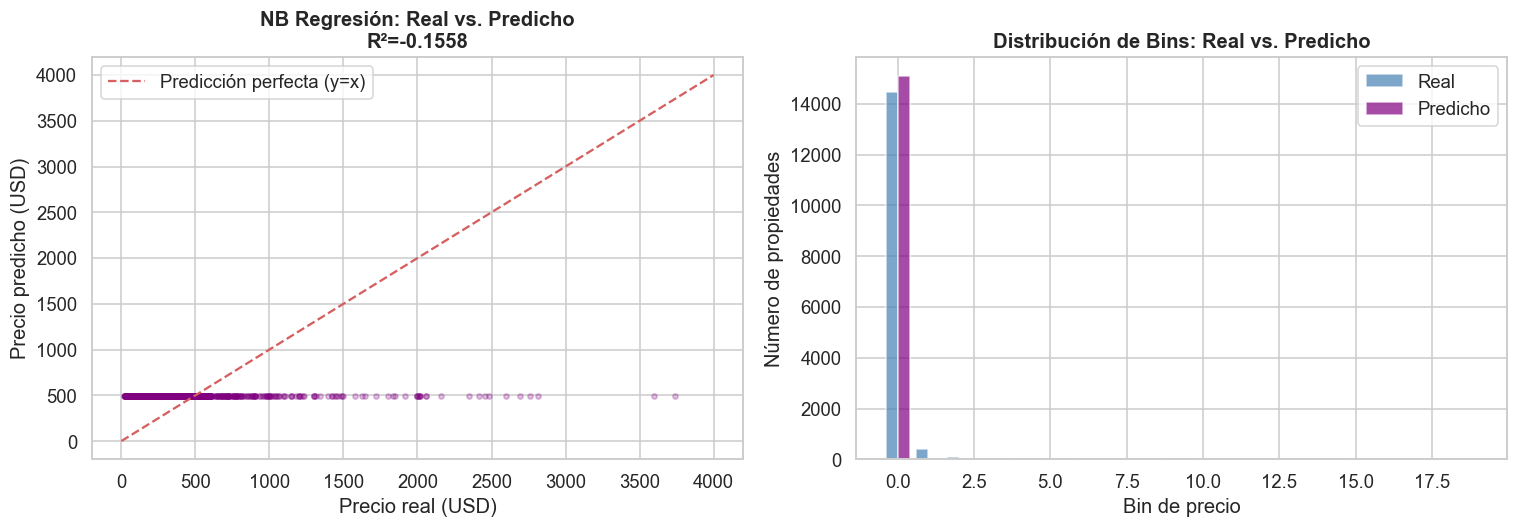

Bins más predichos por NB (top 5):
  Bin  0 ($498): 15,101 propiedades
  Bin 17 ($17501): 6 propiedades


In [6]:
# Actividad 2: Diagnóstico visual y análisis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Real vs Predicho
sample_idx = np.random.default_rng(42).choice(len(y_test), size=min(2000,len(y_test)), replace=False)
y_r = np.array(y_test)[sample_idx]
y_p = yp_nb_reg_test[sample_idx]
mask = (y_r <= 4000) & (y_p <= 4000)
axes[0].scatter(y_r[mask], y_p[mask], alpha=0.25, color='purple', s=12)
axes[0].plot([0,4000],[0,4000],'r--',linewidth=1.5, label='Predicción perfecta (y=x)')
axes[0].set_xlabel('Precio real (USD)')
axes[0].set_ylabel('Precio predicho (USD)')
axes[0].set_title(f'NB Regresión: Real vs. Predicho\nR²={r2_nb_te:.4f}', fontweight='bold')
axes[0].legend()

# Gráfica 2: Distribución de bins predichos vs reales
bins_real = pd.Series(y_test_binned).value_counts().sort_index()
bins_pred = pd.Series(y_pred_bin_test).value_counts().sort_index()
axes[1].bar(bins_real.index - 0.2, bins_real.values, width=0.4,
            label='Real', color='steelblue', alpha=0.7)
axes[1].bar(bins_pred.index + 0.2, bins_pred.values, width=0.4,
            label='Predicho', color='purple', alpha=0.7)
axes[1].set_xlabel('Bin de precio')
axes[1].set_ylabel('Número de propiedades')
axes[1].set_title('Distribución de Bins: Real vs. Predicho', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

# Distribución de bins predichos
print("Bins más predichos por NB (top 5):")
top_bins = pd.Series(y_pred_bin_test).value_counts().head(5)
for b, cnt in top_bins.items():
    print(f"  Bin {b:2d} (${bin_mids[b]:.0f}): {cnt:,} propiedades")


### Interpretación – Regresión con Naive Bayes

El modelo de regresión NB obtiene **R²=-0.1558** y **RMSE=$907.60**, con un MAE de **$388.17**.

Un R² negativo significa que el modelo es **peor que simplemente predecir siempre la mediana del precio** ($191). Este resultado, aunque parece sorprendente, es completamente esperado y tiene una explicación estructural clara.

**Razón principal — el problema de los bins desbalanceados:**
Al discretizar el precio en 20 bins de ancho uniforme (~$1,001 cada uno), el Bin 0 ($8–$1,009) concentra el **95.7% de todas las propiedades** (57,859 de 60,424 en entrenamiento). El modelo aprende que casi siempre la respuesta correcta es "Bin 0", y predice ese bin para 15,101 de 15,107 propiedades del test. El punto medio del Bin 0 es $498, lo que genera un error sistemático gigante para propiedades cuyo precio real es $191 (mediana real).

**Razón secundaria — supuesto de independencia violado:**
Variables como `bathrooms` y `accommodates` tienen correlación r≈0.6, y `longitude`/`latitude` son dependientes geográficamente. GaussianNB trata cada feature como independiente, lo que distorsiona las probabilidades calculadas.

**Conclusión:** NB con discretización uniforme es **inadecuado para regresión de precio** en este dataset. La solución sería usar bins por cuantiles (cada bin con el mismo número de observaciones), pero incluso así NB seguiría siendo inferior a los árboles por el supuesto de independencia.